# sprint 2. inspecao dos dados: supplementary data 2, 4 e 6

projeto: infant dysbiosis predictor  
objetivo: carregar e inspecionar os tres arquivos principais, entender estrutura, tipos de variaveis, missings e distribuicoes antes do pre-processamento.

## 0. imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%pip install openpyxl -q

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 20)

/Users/isa/.zshenv:.:1: no such file or directory: /Users/isa/.cargo/env
Note: you may need to restart the kernel to use updated packages.


## 1. carregamento

In [3]:
df2 = pd.read_excel('../data/Supplementary Data 2.xlsx')
df4 = pd.read_excel('../data/Supplementary Data 4.xlsx')
df6 = pd.read_excel('../data/Supplementary Data 6.xlsx')

print(f'data 2: {df2.shape[0]} amostras x {df2.shape[1]} colunas')
print(f'data 4: {df4.shape[0]} amostras x {df4.shape[1]} colunas')
print(f'data 6: {df6.shape[0]} amostras x {df6.shape[1]} colunas')

data 2: 412 amostras x 564 colunas
data 4: 412 amostras x 3 colunas
data 6: 210 amostras x 7 colunas


## 2. supplementary data 2 — metadados clinicos + microbioma

arquivo principal do estudo: 412 amostras, 564 colunas.  
as primeiras colunas sao variaveis clinicas (parto, dieta, sexo, pH, etc.); as restantes sao abundancias relativas de 550 especies bacterianas.  
separamos as colunas clinicas das colunas de microbioma para facilitar a analise.

In [4]:
# identificar colunas clinicas (as primeiras 14) vs colunas de microbioma
all_cols = list(df2.columns)
clinical_cols = all_cols[:14]
bacteria_cols = [c for c in all_cols[14:] if df2[c].dtype in ['float64', 'float32']]

print(f'colunas clinicas ({len(clinical_cols)}):')
for c in clinical_cols:
    print(f'  {c}: {df2[c].dtype}')

print(f'\nespecies bacterianas: {len(bacteria_cols)}')
print(f'exemplos: {bacteria_cols[:5]}')

colunas clinicas (14):
  sample_id: object
  State: object
  dmm_clusters_taxa: object
  pH: float64
  mother_antibiotics: object
  baby_antibiotics: object
  baby_birthday: datetime64[ns]
  feeding_mode: object
  birth_mode: object
  baby_sex: object
  baby_ethnicity: object
  baby_race: object
  Normed Age at Collection (days): int64
  sample_storage: object

especies bacterianas: 550
exemplos: ['Acetatifactor sp900066565', 'Achromobacter marplatensis', 'Acidaminococcus intestini', 'Acinetobacter towneri', 'Actinobaculum massiliense']


In [5]:
# primeiras linhas das colunas clinicas
df2[clinical_cols].head()

,sample_id,State,dmm_clusters_taxa,pH,mother_antibiotics,baby_antibiotics,baby_birthday,feeding_mode,birth_mode,baby_sex,baby_ethnicity,baby_race,Normed Age at Collection (days),sample_storage
0,sample_1,FL,C2,7.10,No,No,2022-05-30,Mixed,Vaginal,Female,Not Hispanic or Latino,White,46,pbs
1,sample_2,CA,C3,6.28,No,No,2022-06-23,Breast,Vaginal,Female,Not Hispanic or Latino,White,53,pbs
2,sample_3,UT,C2,NaN,No,No,2022-05-29,Breast,Vaginal,Male,Not Hispanic or Latino,White,81,pbs
3,sample_4,WA,C3,6.60,No,No,2022-06-06,Mixed,Vaginal,Female,Not Hispanic or Latino,White,71,pbs
4,sample_5,TX,C1,5.27,No,No,2022-06-14,Breast,Vaginal,Male,Not Hispanic or Latino,White,63,pbs


In [6]:
# estatisticas descritivas das colunas numericas clinicas
df2[clinical_cols].describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
sample_id,412,412,sample_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,412,48,CA,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dmm_clusters_taxa,412,3,C3,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pH,206.0,NaN,NaN,NaN,6.162282,4.55,5.5375,6.06,6.73,8.27,0.775738
mother_antibiotics,412,2,No,402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baby_antibiotics,412,1,No,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baby_birthday,412,NaN,NaN,NaN,2022-08-09 02:54:45.436893184,2002-07-26 00:00:00,2022-08-01 00:00:00,2022-08-21 00:00:00,2022-09-07 00:00:00,2032-06-27 00:00:00,NaN
feeding_mode,412,3,Breast,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_mode,412,2,Vaginal,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baby_sex,412,2,Male,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# missings por coluna clinica
missing = df2[clinical_cols].isnull().sum()
missing_pct = (missing / len(df2) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, 'pct_%': missing_pct})
print('variaveis clinicas com valores ausentes:')
print(missing_df[missing_df['missing'] > 0])
print('\nnota: pH tem 50% de missings — sera excluido como feature nos modelos')

variaveis clinicas com valores ausentes:
    missing  pct_%
pH      206   50.0

nota: pH tem 50% de missings — sera excluido como feature nos modelos


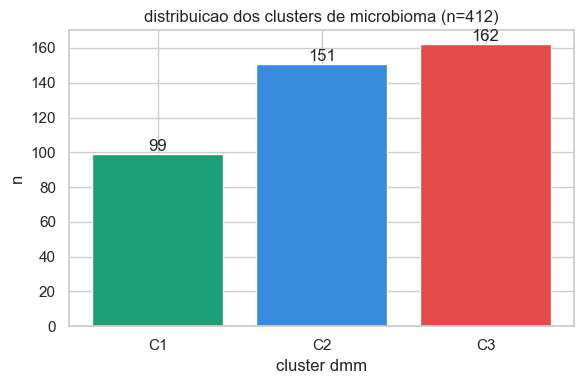

dmm_clusters_taxa
C1    24.0
C2    36.7
C3    39.3
Name: porcent %, dtype: float64


In [8]:
# distribuicao dos clusters dmm (variavel alvo do modelo 2)
cluster_counts = df2['dmm_clusters_taxa'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cluster_counts.index, cluster_counts.values,
              color=['#1D9E75', '#378ADD', '#E24B4A'])
ax.bar_label(bars, fmt='%d')
ax.set_xlabel('cluster dmm')
ax.set_ylabel('n')
ax.set_title('distribuicao dos clusters de microbioma (n=412)')
plt.tight_layout()
plt.show()

print((cluster_counts / cluster_counts.sum() * 100).round(1).rename('porcent %'))

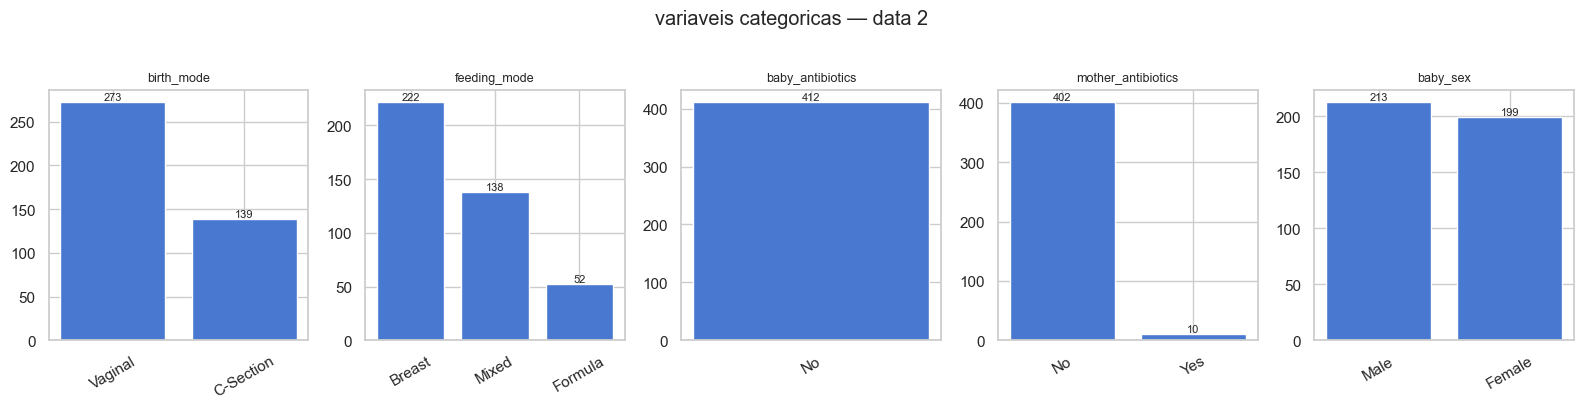

nota: baby_antibiotics = No para TODAS as 412 amostras — variavel sera descartada


In [9]:
# distribuicao das variaveis categoricas clinicas
cat_cols = ['birth_mode', 'feeding_mode', 'baby_antibiotics',
            'mother_antibiotics', 'baby_sex']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))

for ax, col in zip(axes, cat_cols):
    counts = df2[col].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.bar_label(ax.containers[0], fmt='%d', fontsize=8)

plt.suptitle('variaveis categoricas — data 2', y=1.02)
plt.tight_layout()
plt.show()

print('nota: baby_antibiotics = No para TODAS as 412 amostras — variavel sera descartada')

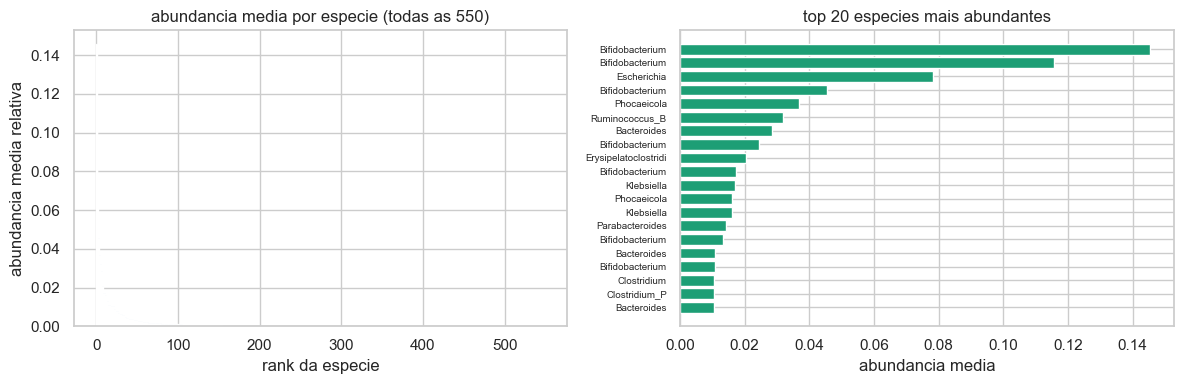

In [10]:
# distribuicao da abundancia bacteriana
bacteria_means = df2[bacteria_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(bacteria_means)), bacteria_means.values, color='#378ADD')
axes[0].set_title('abundancia media por especie (todas as 550)')
axes[0].set_xlabel('rank da especie')
axes[0].set_ylabel('abundancia media relativa')

top20 = bacteria_means.head(20)
axes[1].barh(range(20), top20.values[::-1], color='#1D9E75')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([n.split(' ')[0][:20] for n in top20.index[::-1]], fontsize=7)
axes[1].set_title('top 20 especies mais abundantes')
axes[1].set_xlabel('abundancia media')

plt.tight_layout()
plt.show()

## 2.1 missings das variaveis clinicas

In [11]:
missing = df2[clinical_cols].isnull().sum()
missing_pct = (missing / len(df2) * 100).round(1)

missing_df = pd.DataFrame({
    'tipo': df2[clinical_cols].dtypes.astype(str),
    'n_missing': missing,
    'pct_%': missing_pct,
    'n_validos': len(df2) - missing
}).sort_values('n_missing', ascending=False)

print(f'total de amostras: {len(df2)}')
print()
print(missing_df.to_string())

total de amostras: 412

                                           tipo  n_missing  pct_%  n_validos
pH                                      float64        206   50.0        206
sample_id                                object          0    0.0        412
State                                    object          0    0.0        412
dmm_clusters_taxa                        object          0    0.0        412
mother_antibiotics                       object          0    0.0        412
baby_antibiotics                         object          0    0.0        412
baby_birthday                    datetime64[ns]          0    0.0        412
feeding_mode                             object          0    0.0        412
birth_mode                               object          0    0.0        412
baby_sex                                 object          0    0.0        412
baby_ethnicity                           object          0    0.0        412
baby_race                                object     

## 2.2 valores unicos das variaveis categoricas

In [12]:
cat_clinical = ['dmm_clusters_taxa', 'birth_mode', 'feeding_mode',
                'baby_antibiotics', 'mother_antibiotics',
                'baby_sex', 'baby_ethnicity', 'baby_race', 'sample_storage']

for col in cat_clinical:
    vc = df2[col].value_counts(dropna=False)
    vc_pct = (vc / len(df2) * 100).round(1)
    print(f'--- {col} ({df2[col].nunique()} valores unicos) ---')
    for val, n in vc.items():
        print(f'  {str(val):<45} n={n:>4}  ({vc_pct[val]:.1f}%)')
    print()

--- dmm_clusters_taxa (3 valores unicos) ---
  C3                                            n= 162  (39.3%)
  C2                                            n= 151  (36.7%)
  C1                                            n=  99  (24.0%)

--- birth_mode (2 valores unicos) ---
  Vaginal                                       n= 273  (66.3%)
  C-Section                                     n= 139  (33.7%)

--- feeding_mode (3 valores unicos) ---
  Breast                                        n= 222  (53.9%)
  Mixed                                         n= 138  (33.5%)
  Formula                                       n=  52  (12.6%)

--- baby_antibiotics (1 valores unicos) ---
  No                                            n= 412  (100.0%)

--- mother_antibiotics (2 valores unicos) ---
  No                                            n= 402  (97.6%)
  Yes                                           n=  10  (2.4%)

--- baby_sex (2 valores unicos) ---
  Male                                    

## 2.3 distribuicao das variaveis categoricas por cluster DMM\n\ncrosstab proporcional: para cada variavel, qual a distribuicao de clusters dentro de cada categoria?  \nidentifica quais variaveis tem associacao visivel com o cluster.

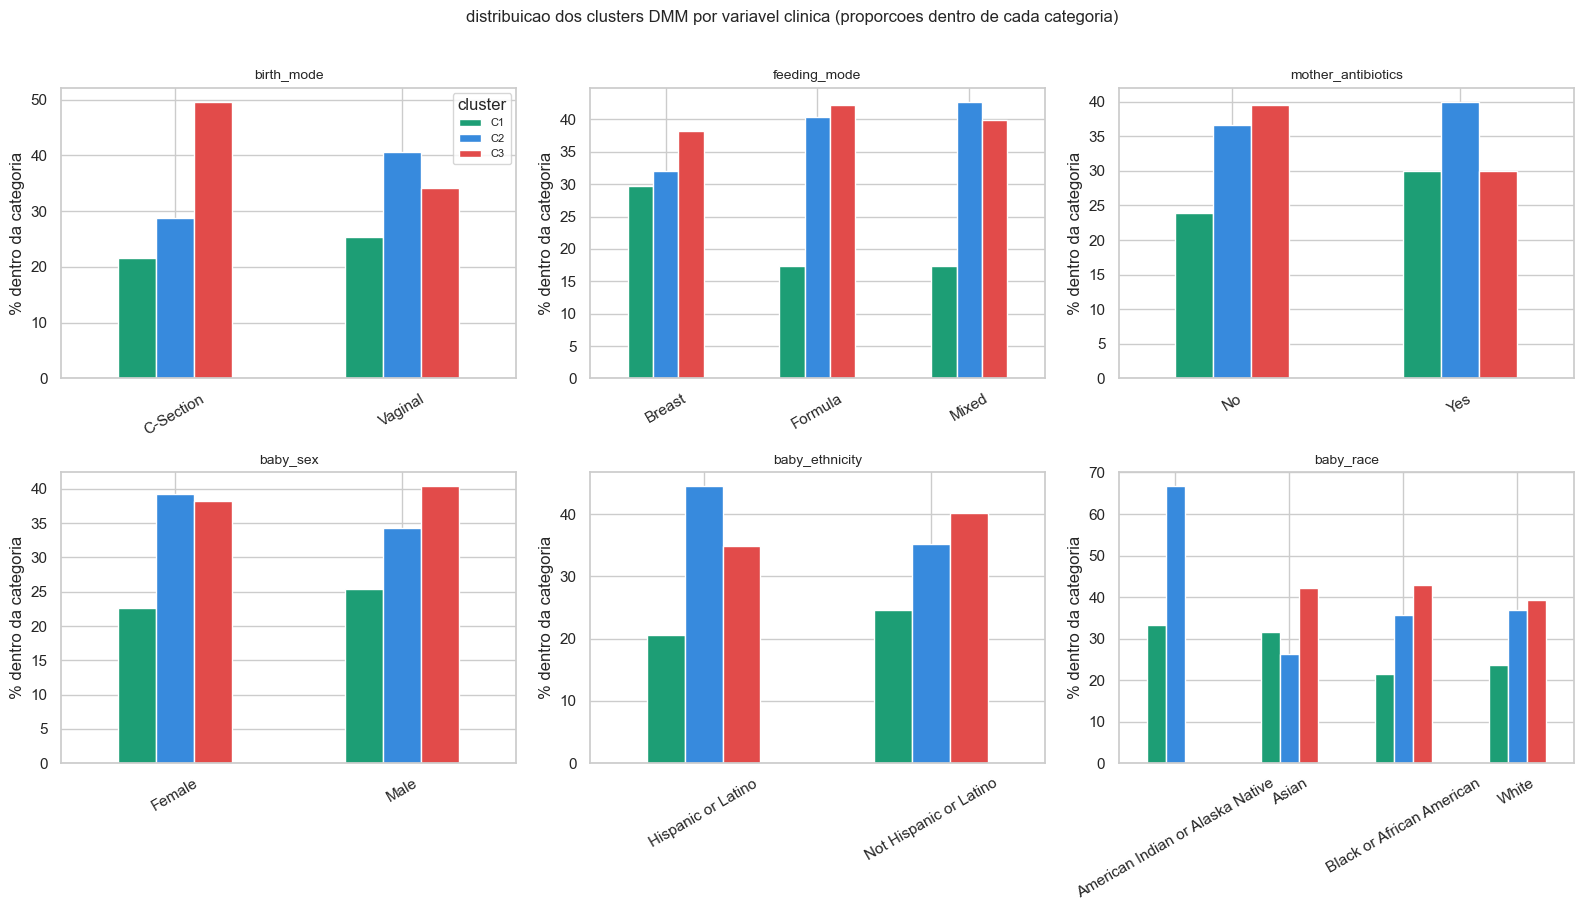

In [13]:
cols_to_cross = ['birth_mode', 'feeding_mode', 'mother_antibiotics',
                 'baby_sex', 'baby_ethnicity', 'baby_race']

colors = ['#1D9E75', '#378ADD', '#E24B4A']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, cols_to_cross):
    ct = pd.crosstab(df2[col], df2['dmm_clusters_taxa'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=colors, legend=(col == 'birth_mode'))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('% dentro da categoria')
    if col == 'birth_mode':
        ax.legend(title='cluster', fontsize=8)

plt.suptitle('distribuicao dos clusters DMM por variavel clinica (proporcoes dentro de cada categoria)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 2.4 distribuicao das variaveis numericas

In [14]:
num_cols = ['Normed Age at Collection (days)', 'pH']

for col in num_cols:
    serie = df2[col].dropna()
    print(f'=== {col} ===')
    print(f'  n validos : {len(serie)} / {len(df2)} ({len(serie)/len(df2)*100:.0f}%)')
    print(f'  media     : {serie.mean():.2f}')
    print(f'  mediana   : {serie.median():.2f}')
    print(f'  std       : {serie.std():.2f}')
    print(f'  min / max : {serie.min():.2f} / {serie.max():.2f}')
    print(f'  p25 / p75 : {serie.quantile(.25):.2f} / {serie.quantile(.75):.2f}')
    print()

=== Normed Age at Collection (days) ===
  n validos : 412 / 412 (100%)
  media     : 54.34
  mediana   : 53.00
  std       : 14.15
  min / max : 6.00 / 155.00
  p25 / p75 : 44.00 / 61.00

=== pH ===
  n validos : 206 / 412 (50%)
  media     : 6.16
  mediana   : 6.06
  std       : 0.78
  min / max : 4.55 / 8.27
  p25 / p75 : 5.54 / 6.73



/var/folders/85/5z9rshzs1v3brh60d8mh67zm0000gn/T/ipykernel_11232/2222960042.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cluster, labels=['C1', 'C2', 'C3'],
/var/folders/85/5z9rshzs1v3brh60d8mh67zm0000gn/T/ipykernel_11232/2222960042.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_ph_cluster, labels=['C1', 'C2', 'C3'],


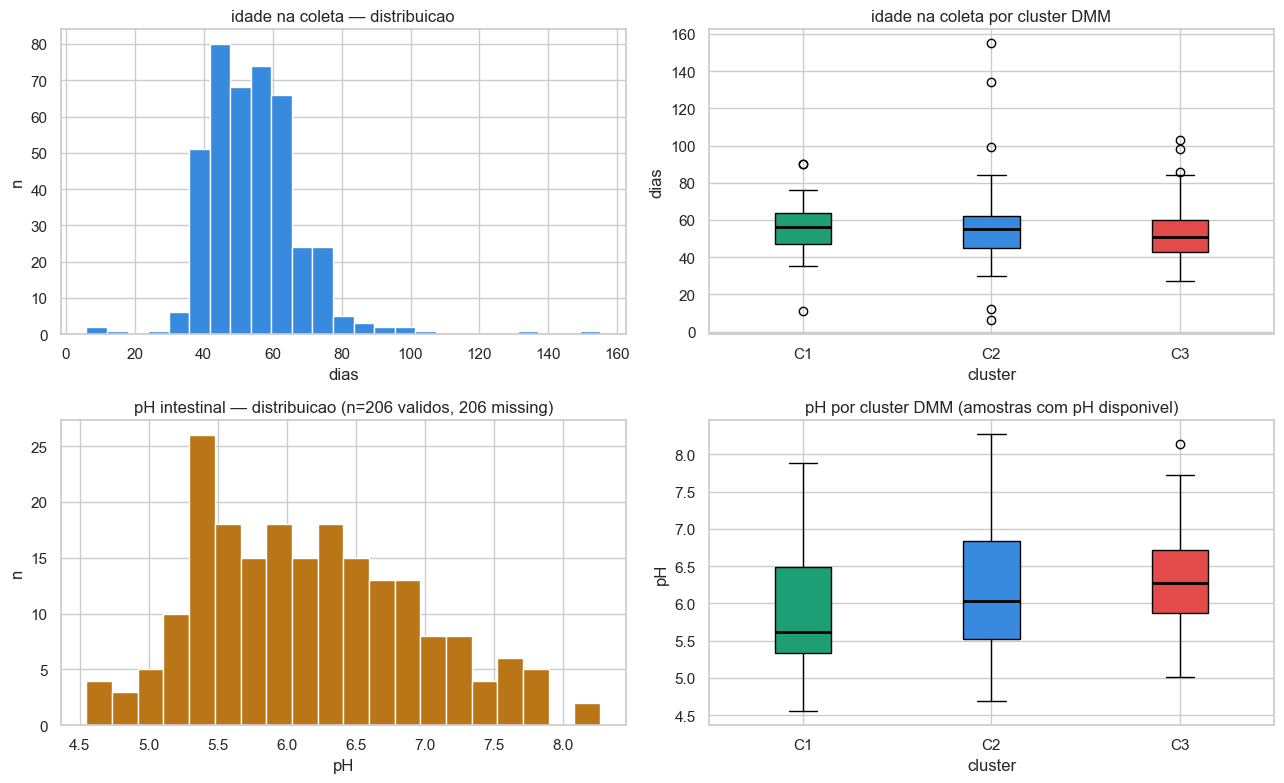

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# idade: histograma
ax = axes[0, 0]
ax.hist(df2['Normed Age at Collection (days)'], bins=25,
        color='#378ADD', edgecolor='white')
ax.set_title('idade na coleta — distribuicao')
ax.set_xlabel('dias')
ax.set_ylabel('n')

# idade: boxplot por cluster
ax = axes[0, 1]
data_by_cluster = [df2.loc[df2['dmm_clusters_taxa'] == c,
                            'Normed Age at Collection (days)'].dropna()
                   for c in ['C1', 'C2', 'C3']]
bp = ax.boxplot(data_by_cluster, labels=['C1', 'C2', 'C3'],
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#1D9E75', '#378ADD', '#E24B4A']):
    patch.set_facecolor(color)
ax.set_title('idade na coleta por cluster DMM')
ax.set_xlabel('cluster')
ax.set_ylabel('dias')

# pH: histograma (apenas validos)
ax = axes[1, 0]
ph_valid = df2['pH'].dropna()
ax.hist(ph_valid, bins=20, color='#BA7517', edgecolor='white')
ax.set_title(f'pH intestinal — distribuicao (n={len(ph_valid)} validos, {len(df2)-len(ph_valid)} missing)')
ax.set_xlabel('pH')
ax.set_ylabel('n')

# pH: boxplot por cluster (apenas validos)
ax = axes[1, 1]
df2_ph = df2.dropna(subset=['pH'])
data_ph_cluster = [df2_ph.loc[df2_ph['dmm_clusters_taxa'] == c, 'pH']
                   for c in ['C1', 'C2', 'C3']]
bp2 = ax.boxplot(data_ph_cluster, labels=['C1', 'C2', 'C3'],
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], ['#1D9E75', '#378ADD', '#E24B4A']):
    patch.set_facecolor(color)
ax.set_title('pH por cluster DMM (amostras com pH disponivel)')
ax.set_xlabel('cluster')
ax.set_ylabel('pH')

plt.tight_layout()
plt.show()

## 2.5 resumo: decisoes sobre as variaveis clinicas\n\n| variavel | tipo | missings | valores unicos | decisao |\n|---|---|---|---|---|\n| `dmm_clusters_taxa` | cat | 0 | C1, C2, C3 | **target modelo 2** |\n| `birth_mode` | cat | 0 | Vaginal, C-section | **feature** |\n| `feeding_mode` | cat | 0 | Breast, Formula, Mixed | **feature** |\n| `mother_antibiotics` | cat | 0 | No, Yes | **feature** |\n| `baby_sex` | cat | 0 | Female, Male | **feature** |\n| `baby_ethnicity` | cat | 0 | 2 valores | **feature** |\n| `baby_race` | cat | 0 | varias | **feature** (agrupar minoria em 'Other') |\n| `Normed Age at Collection (days)` | num | 0 | continua | **feature** |\n| `pH` | num | 206 (50%) | continua | **descartada** |\n| `baby_antibiotics` | cat | 0 | apenas 'No' | **descartada** (variancia zero) |\n| `baby_birthday` | data | 0 | — | **descartada** (nao e feature clinica) |\n| `sample_storage` | cat | 0 | — | **descartada** (variavel de controle) |

## 3. supplementary data 4 — AMR e fatores de virulencia

412 amostras, 3 colunas: `sample_id`, `amr_gene_sum_abundance`, `vf_sum_abundance`.  
sem missings. essas variaveis capturam o perfil de risco genetico do microbioma e serao incluidas como features nos dois modelos.

In [16]:
print('shape:', df4.shape)
print('missings:', df4.isnull().sum().to_dict())
print()
df4.head()

shape: (412, 3)
missings: {'sample_id': 0, 'amr_gene_sum_abundance': 0, 'vf_sum_abundance': 0}



,sample_id,amr_gene_sum_abundance,vf_sum_abundance
0,sample_59,0.001594,0.001324
1,sample_103,0.002816,0.000873
2,sample_371,0.001735,0.000760
3,sample_99,0.001767,0.001174
4,sample_25,0.001577,0.000016


In [17]:
df4.describe().round(6)

,amr_gene_sum_abundance,vf_sum_abundance
count,412.000000,412.000000
mean,0.003218,0.003292
std,0.001149,0.004505
min,0.001205,0.000000
25%,0.002280,0.000511
50%,0.003095,0.001447
75%,0.003988,0.004351
max,0.007359,0.032425


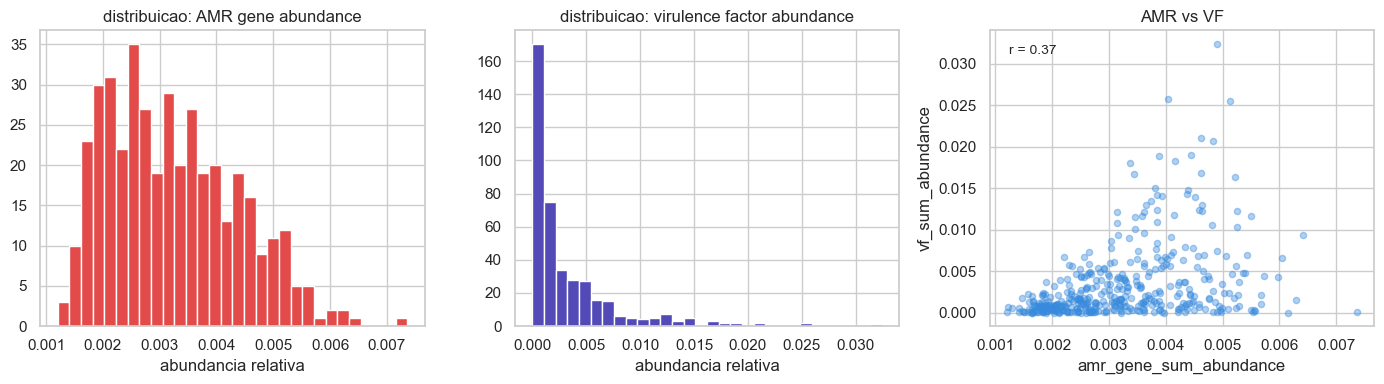

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histograma AMR
axes[0].hist(df4['amr_gene_sum_abundance'], bins=30, color='#E24B4A', edgecolor='white')
axes[0].set_title('distribuicao: AMR gene abundance')
axes[0].set_xlabel('abundancia relativa')

# histograma VF
axes[1].hist(df4['vf_sum_abundance'], bins=30, color='#534AB7', edgecolor='white')
axes[1].set_title('distribuicao: virulence factor abundance')
axes[1].set_xlabel('abundancia relativa')

# scatter AMR vs VF
axes[2].scatter(df4['amr_gene_sum_abundance'], df4['vf_sum_abundance'],
                alpha=0.4, color='#378ADD', s=20)
axes[2].set_xlabel('amr_gene_sum_abundance')
axes[2].set_ylabel('vf_sum_abundance')
axes[2].set_title('AMR vs VF')
corr = df4['amr_gene_sum_abundance'].corr(df4['vf_sum_abundance'])
axes[2].text(0.05, 0.95, f'r = {corr:.2f}', transform=axes[2].transAxes,
             va='top', fontsize=10)

plt.tight_layout()
plt.show()

## 4. supplementary data 6 — desfechos aos 2 anos

210 familias com follow-up (de 412 iniciais).  
variavel alvo do modelo 1: `adverse_outcomes` (0/1 — pelo menos uma condicao atopica diagnosticada ate os 2 anos).  
nota: coluna de eczema tem 4 entradas com valor `0` em vez de `No` — encoding inconsistente, tratar no pre-processamento.

In [19]:
print('shape:', df6.shape)
print('missings:', df6.isnull().sum().to_dict())
print()
df6.head(10)

shape: (210, 7)
missings: {'sample_id': 0, 'dmm_clusters_taxa_paper': 0, 'adverse_outcomes': 0, 'antibiotics_first_2_years': 0, 'allergies': 0, 'Has_your_child_been_diagnosed_with_asthma': 0, 'Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis': 0}



,sample_id,dmm_clusters_taxa_paper,adverse_outcomes,antibiotics_first_2_years,allergies,Has_your_child_been_diagnosed_with_asthma,Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis
0,sample_412,2,1,1,No,No,Yes
1,sample_404,3,0,0,No,No,No
2,sample_411,2,0,0,No,No,0
3,sample_384,3,0,0,No,No,No
4,sample_409,3,1,1,Yes,No,No
5,sample_410,3,0,1,No,No,No
6,sample_344,3,0,0,No,No,No
7,sample_362,3,1,0,No,No,Yes
8,sample_399,3,0,0,No,No,No
9,sample_403,3,0,1,No,No,No


In [20]:
df6.dtypes

sample_id                                                         object
dmm_clusters_taxa_paper                                            int64
adverse_outcomes                                                   int64
antibiotics_first_2_years                                          int64
allergies                                                         object
Has_your_child_been_diagnosed_with_asthma                         object
Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis    object
dtype: object

In [21]:
# valores unicos por coluna categorica
for col in ['allergies',
            'Has_your_child_been_diagnosed_with_asthma',
            'Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis']:
    print(f'{col}:')
    print(f'  {df6[col].value_counts().to_dict()}')

print('\nnota: eczema tem valor 0 (provavelmente missing) em vez de No — tratar no pre-processamento')

allergies:
  {'No': 184, 'Yes': 26}
Has_your_child_been_diagnosed_with_asthma:
  {'No': 203, 'Yes': 7}
Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis:
  {'No': 162, 'Yes': 44, 0: 4}

nota: eczema tem valor 0 (provavelmente missing) em vez de No — tratar no pre-processamento


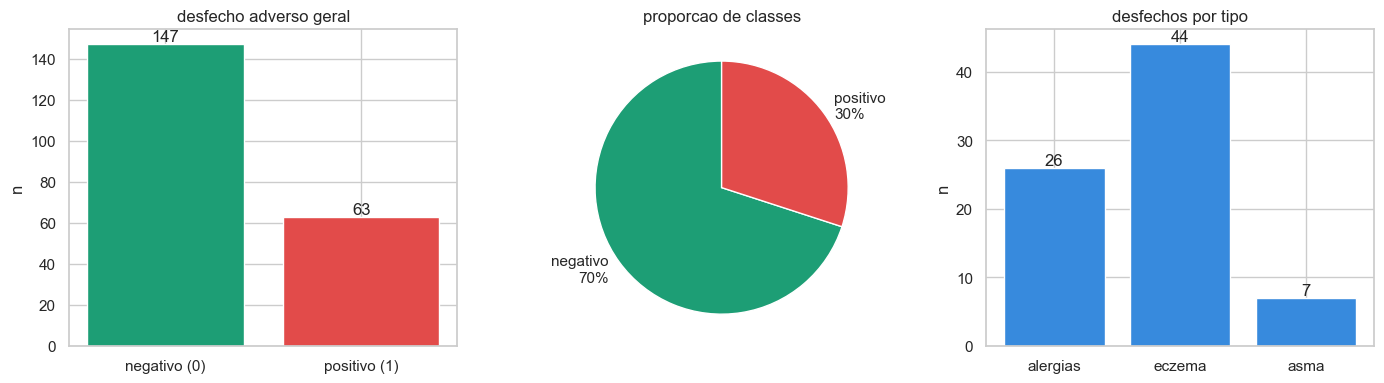

positivos: 63 / 210 (30.0%)
nota: desbalanceamento ~30/70 justifica uso de recall como metrica principal no modelo 1


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# desfecho adverso geral
counts = df6['adverse_outcomes'].value_counts().sort_index()
bars = axes[0].bar(['negativo (0)', 'positivo (1)'], counts.values,
                   color=['#1D9E75', '#E24B4A'])
axes[0].bar_label(bars, fmt='%d')
axes[0].set_title('desfecho adverso geral')
axes[0].set_ylabel('n')

pct = counts / counts.sum() * 100
axes[1].pie(pct.values,
            labels=[f'negativo\n{pct[0]:.0f}%', f'positivo\n{pct[1]:.0f}%'],
            colors=['#1D9E75', '#E24B4A'], startangle=90)
axes[1].set_title('proporcao de classes')

# desfechos por tipo
tipo_counts = {
    'alergias': (df6['allergies'] == 'Yes').sum(),
    'eczema': (df6['Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis'] == 'Yes').sum(),
    'asma':   (df6['Has_your_child_been_diagnosed_with_asthma'] == 'Yes').sum()
}
bars2 = axes[2].bar(tipo_counts.keys(), tipo_counts.values(), color='#378ADD')
axes[2].bar_label(bars2, fmt='%d')
axes[2].set_title('desfechos por tipo')
axes[2].set_ylabel('n')

plt.tight_layout()
plt.show()

print(f'positivos: {counts[1]} / {len(df6)} ({pct[1]:.1f}%)')
print('nota: desbalanceamento ~30/70 justifica uso de recall como metrica principal no modelo 1')

In [23]:
# antibioticos nos primeiros 2 anos
ab2 = df6['antibiotics_first_2_years'].value_counts()
print('uso de antibioticos (primeiros 2 anos):')
print(ab2)
print(f'\n{ab2[1]/len(df6)*100:.1f}% das criancas usaram antibioticos ate os 2 anos')
print('sera incluida como covariate no modelo 1 (metodologia do paper original)')

uso de antibioticos (primeiros 2 anos):
antibiotics_first_2_years
1    113
0     97
Name: count, dtype: int64

53.8% das criancas usaram antibioticos ate os 2 anos
sera incluida como covariate no modelo 1 (metodologia do paper original)


## 5. analise dos clusters DMM e do desfecho adverso\n\nessa secao integra os tres arquivos para analisar:\n- a distribuicao dos clusters DMM e sua relacao com as variaveis clinicas\n- a distribuicao do desfecho adverso\n- a associacao entre cluster DMM e desfecho adverso (conecta os dois modelos)

### 5.1 distribuicao dos clusters DMM (n=412)

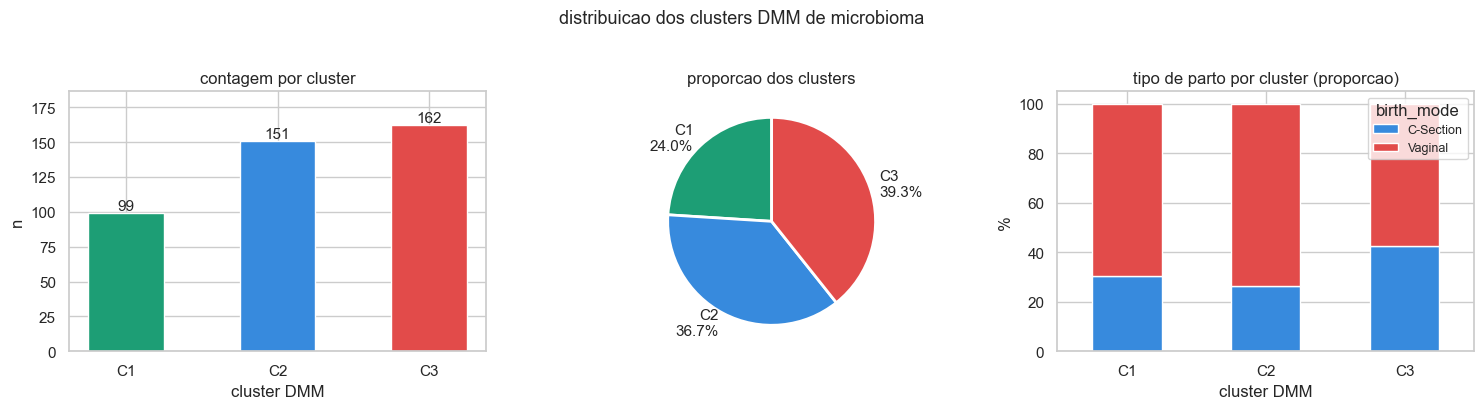

                     n     %
dmm_clusters_taxa           
C1                  99  24.0
C2                 151  36.7
C3                 162  39.3


In [24]:
cluster_counts = df2['dmm_clusters_taxa'].value_counts().sort_index()
cluster_pct = (cluster_counts / cluster_counts.sum() * 100).round(1)
colors_c = ['#1D9E75', '#378ADD', '#E24B4A']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# barplot com contagens
bars = axes[0].bar(cluster_counts.index, cluster_counts.values, color=colors_c, width=0.5)
axes[0].bar_label(bars, fmt='%d', fontsize=11)
axes[0].set_ylim(0, cluster_counts.max() * 1.15)
axes[0].set_xlabel('cluster DMM')
axes[0].set_ylabel('n')
axes[0].set_title('contagem por cluster')

# pizza com percentuais
axes[1].pie(cluster_pct.values,
            labels=[f'{c}\n{p:.1f}%' for c, p in zip(cluster_counts.index, cluster_pct.values)],
            colors=colors_c, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('proporcao dos clusters')

# barras empilhadas com breakdown de birth_mode
ct = pd.crosstab(df2['dmm_clusters_taxa'], df2['birth_mode'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[2],
            color=['#378ADD', '#E24B4A'], width=0.5)
axes[2].set_title('tipo de parto por cluster (proporcao)')
axes[2].set_xlabel('cluster DMM')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='birth_mode', fontsize=9)

plt.suptitle('distribuicao dos clusters DMM de microbioma', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'n': cluster_counts, '%': cluster_pct}))

### 5.2 perfil clinico de cada cluster\n\nheatmap de proporcoes: para cada combinacao (cluster, variavel), qual o valor modal e sua frequencia?  \npermite ver rapidamente o \"perfil tipico\" de cada cluster.

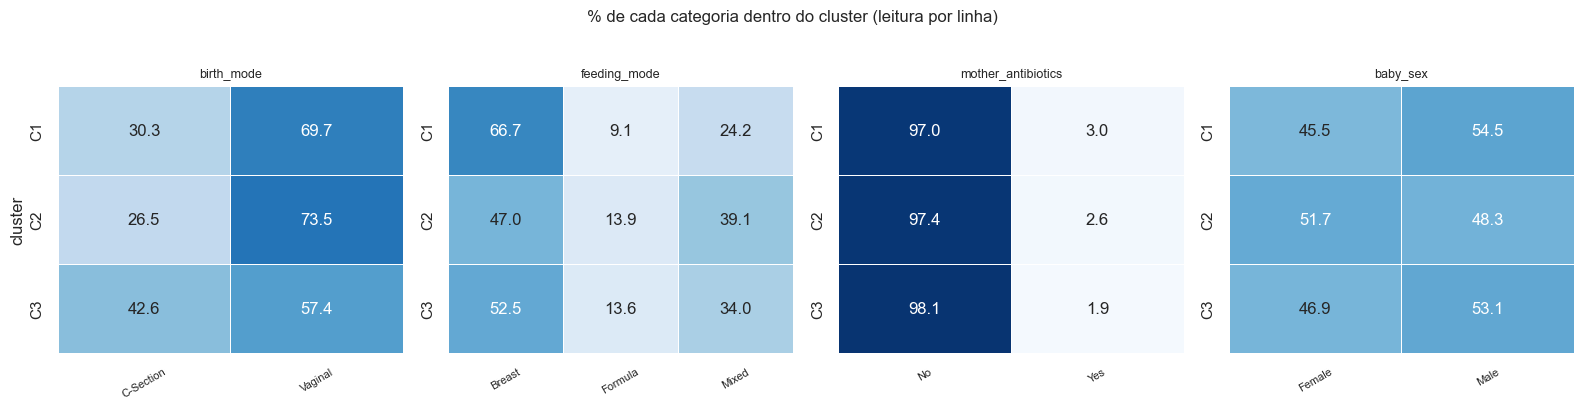

medias numericas por cluster:
                   mean  median   std
dmm_clusters_taxa                    
C1                 55.9    56.0  12.6
C2                 55.0    55.0  16.3
C3                 52.8    51.0  12.8


In [25]:
features_cat = ['birth_mode', 'feeding_mode', 'mother_antibiotics', 'baby_sex']

fig, axes = plt.subplots(1, len(features_cat), figsize=(16, 4))

for ax, feat in zip(axes, features_cat):
    ct = pd.crosstab(df2['dmm_clusters_taxa'], df2[feat], normalize='index') * 100
    sns.heatmap(ct, ax=ax, annot=True, fmt='.1f', cmap='Blues',
                cbar=False, linewidths=0.5, vmin=0, vmax=100)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('cluster' if feat == 'birth_mode' else '')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('% de cada categoria dentro do cluster (leitura por linha)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# tabela numerica resumida
print('medias numericas por cluster:')
num_by_cluster = df2.groupby('dmm_clusters_taxa')[
    'Normed Age at Collection (days)'
].agg(['mean', 'median', 'std']).round(1)
print(num_by_cluster)

### 5.3 distribuicao do desfecho adverso (n=210)

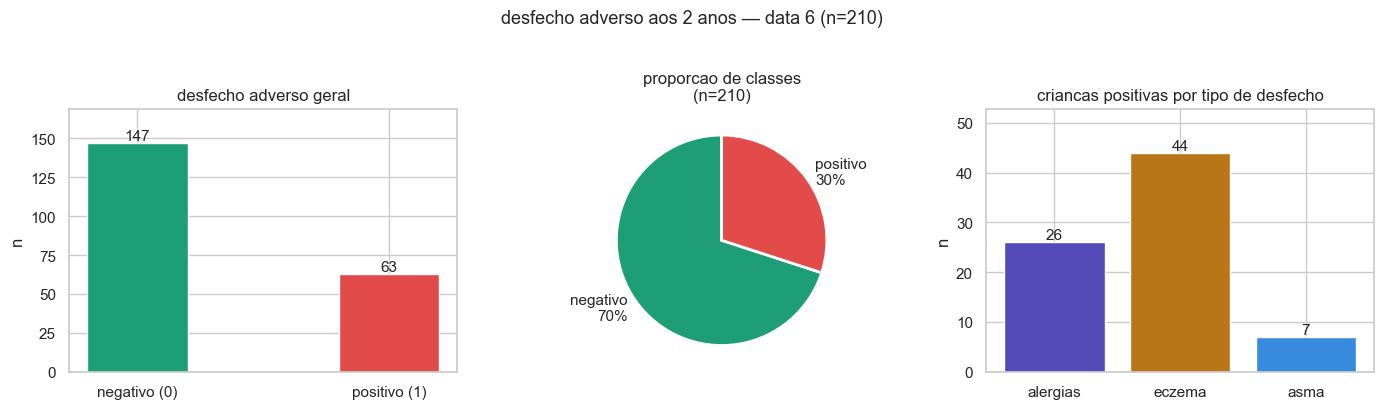

positivos: 63 / 210 (30.0%)
negativos: 147 / 210 (70.0%)

desfechos sobrepostos (uma crianca pode ter mais de um):
  alergias: 26 (12.4%)
  eczema: 44 (21.0%)
  asma: 7 (3.3%)


In [26]:
ao = df6['adverse_outcomes'].value_counts().sort_index()
ao_pct = (ao / ao.sum() * 100).round(1)

# normalizar eczema (0 → No) para contar desfechos por tipo corretamente
df6_clean = df6.copy()
eczema_col = 'Has_your_child_been_diagnosed_with_eczema_or_atopic_dermatitis'
df6_clean[eczema_col] = df6_clean[eczema_col].replace(0, 'No')

tipo = {
    'alergias' : (df6_clean['allergies'] == 'Yes').sum(),
    'eczema'   : (df6_clean[eczema_col] == 'Yes').sum(),
    'asma'     : (df6_clean['Has_your_child_been_diagnosed_with_asthma'] == 'Yes').sum(),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# barplot desfecho geral
bars = axes[0].bar(['negativo (0)', 'positivo (1)'], ao.values,
                   color=['#1D9E75', '#E24B4A'], width=0.4)
axes[0].bar_label(bars, fmt='%d', fontsize=11)
axes[0].set_ylim(0, ao.max() * 1.15)
axes[0].set_title('desfecho adverso geral')
axes[0].set_ylabel('n')

# pizza
axes[1].pie(ao_pct.values,
            labels=[f'negativo\n{ao_pct[0]:.0f}%', f'positivo\n{ao_pct[1]:.0f}%'],
            colors=['#1D9E75', '#E24B4A'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'proporcao de classes\n(n={len(df6)})')

# desfechos por tipo
bars2 = axes[2].bar(tipo.keys(), tipo.values(), color=['#534AB7', '#BA7517', '#378ADD'])
axes[2].bar_label(bars2, fmt='%d', fontsize=11)
axes[2].set_ylim(0, max(tipo.values()) * 1.2)
axes[2].set_title('criancas positivas por tipo de desfecho')
axes[2].set_ylabel('n')

plt.suptitle('desfecho adverso aos 2 anos — data 6 (n=210)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'positivos: {ao[1]} / {len(df6)} ({ao_pct[1]:.1f}%)')
print(f'negativos: {ao[0]} / {len(df6)} ({ao_pct[0]:.1f}%)')
print(f'\ndesfechos sobrepostos (uma crianca pode ter mais de um):')
for k, v in tipo.items():
    print(f'  {k}: {v} ({v/len(df6)*100:.1f}%)')

### 5.4 cluster DMM × desfecho adverso\n\npara os 210 bebes com follow-up: qual a taxa de desfecho adverso dentro de cada cluster?  \nessa e a analise central que conecta os dois modelos — se o cluster preve o desfecho, o modelo 2 tem valor clinico indireto.

In [27]:
# merge data 2 (clinical) + data 6 (outcomes) para os 210 com follow-up
clinical_cols_select = ['sample_id', 'dmm_clusters_taxa', 'birth_mode',
                        'feeding_mode', 'mother_antibiotics', 'baby_sex',
                        'Normed Age at Collection (days)']
df_merged = df2[clinical_cols_select].merge(df6[['sample_id', 'adverse_outcomes',
                                                  'antibiotics_first_2_years']],
                                             on='sample_id', how='inner')

print(f'dataset merged: {df_merged.shape}')
print(f'clusters presentes: {sorted(df_merged["dmm_clusters_taxa"].unique())}')

# taxa de desfecho por cluster
rate = df_merged.groupby('dmm_clusters_taxa')['adverse_outcomes'].agg(
    n='count', positivos='sum'
)
rate['taxa_%'] = (rate['positivos'] / rate['n'] * 100).round(1)

# risco relativo em relacao ao C1 (cluster saudavel como referencia)
baseline = rate.loc['C1', 'taxa_%']
rate['risco_relativo_vs_C1'] = (rate['taxa_%'] / baseline).round(2)

print()
print(rate)

dataset merged: (210, 9)
clusters presentes: ['C1', 'C2', 'C3']

                    n  positivos  taxa_%  risco_relativo_vs_C1
dmm_clusters_taxa                                             
C1                 52         10    19.2                  1.00
C2                 68         23    33.8                  1.76
C3                 90         30    33.3                  1.73


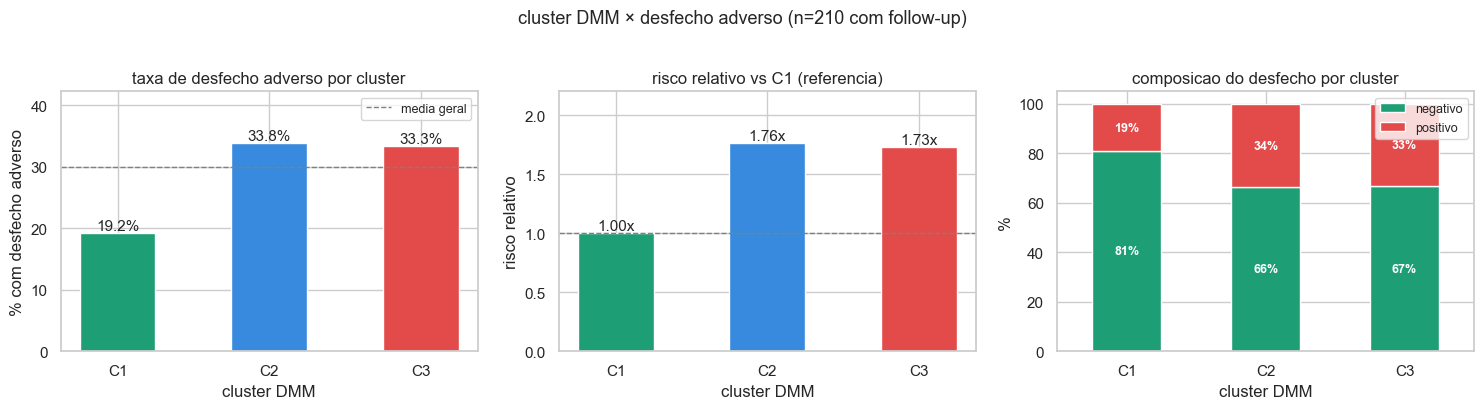

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# taxa de desfecho por cluster (barplot)
bars = axes[0].bar(rate.index, rate['taxa_%'], color=colors_c, width=0.5)
axes[0].bar_label(bars, labels=[f'{v:.1f}%' for v in rate['taxa_%']], fontsize=11)
axes[0].set_ylim(0, rate['taxa_%'].max() * 1.25)
axes[0].set_xlabel('cluster DMM')
axes[0].set_ylabel('% com desfecho adverso')
axes[0].set_title('taxa de desfecho adverso por cluster')
axes[0].axhline(df_merged['adverse_outcomes'].mean() * 100, color='gray',
                linestyle='--', linewidth=1, label='media geral')
axes[0].legend(fontsize=9)

# risco relativo vs C1
bars2 = axes[1].bar(rate.index, rate['risco_relativo_vs_C1'], color=colors_c, width=0.5)
axes[1].bar_label(bars2, labels=[f'{v:.2f}x' for v in rate['risco_relativo_vs_C1']], fontsize=11)
axes[1].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, rate['risco_relativo_vs_C1'].max() * 1.25)
axes[1].set_xlabel('cluster DMM')
axes[1].set_ylabel('risco relativo')
axes[1].set_title('risco relativo vs C1 (referencia)')

# stacked bar: proporcao positivo/negativo por cluster
ct = pd.crosstab(df_merged['dmm_clusters_taxa'], df_merged['adverse_outcomes'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = ['negativo', 'positivo']
ct_pct.plot(kind='bar', stacked=True, ax=axes[2],
            color=['#1D9E75', '#E24B4A'], width=0.5)
axes[2].set_title('composicao do desfecho por cluster')
axes[2].set_xlabel('cluster DMM')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=9)
for bar in axes[2].patches:
    h = bar.get_height()
    if h > 5:
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_y() + h / 2, f'{h:.0f}%',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.suptitle('cluster DMM × desfecho adverso (n=210 com follow-up)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.5 desfecho adverso × variaveis clinicas\n\npara o subset de 210: qual a taxa de desfecho dentro de cada categoria das variaveis clinicas?

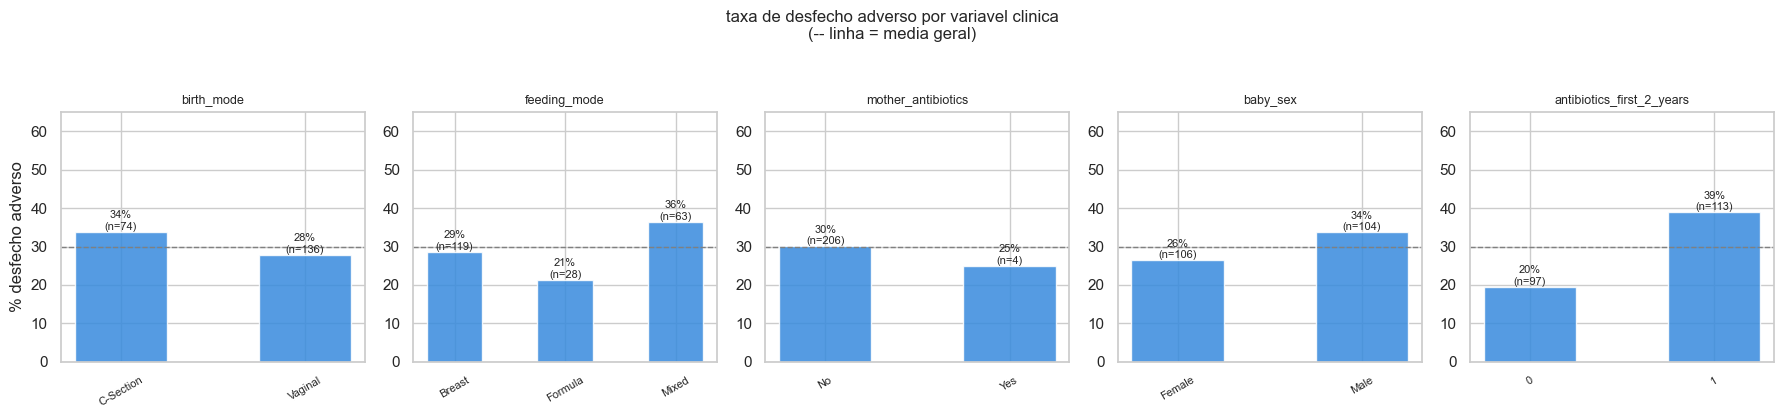

In [29]:
feats = ['birth_mode', 'feeding_mode', 'mother_antibiotics',
         'baby_sex', 'antibiotics_first_2_years']

fig, axes = plt.subplots(1, len(feats), figsize=(18, 4))

for ax, feat in zip(axes, feats):
    grp = df_merged.groupby(feat)['adverse_outcomes'].agg(
        n='count', positivos='sum'
    )
    grp['taxa_%'] = (grp['positivos'] / grp['n'] * 100).round(1)
    bars = ax.bar(grp.index.astype(str), grp['taxa_%'],
                  color='#378ADD', alpha=0.85, width=0.5)
    ax.bar_label(bars, labels=[f'{v:.0f}%\n(n={n})' for v, n in
                                zip(grp['taxa_%'], grp['n'])], fontsize=8)
    ax.axhline(df_merged['adverse_outcomes'].mean() * 100, color='gray',
               linestyle='--', linewidth=1)
    ax.set_ylim(0, 65)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('% desfecho adverso' if feat == 'birth_mode' else '')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('taxa de desfecho adverso por variavel clinica\n(-- linha = media geral)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 6. merge e exportacao dos datasets limpos\n\ndois datasets distintos para os dois modelos:\n- **modelo 1** (desfecho adverso, binario): data 2 + data 4 + data 6 → n=210\n- **modelo 2** (cluster DMM, multiclasse): data 2 + data 4 → n=412\n\nfeatures excluidas: `baby_antibiotics` (variancia zero), `pH` (50% missing), `baby_birthday`, `sample_storage`.

In [31]:
FEATURES = [
    'birth_mode',
    'feeding_mode',
    'mother_antibiotics',
    'baby_sex',
    'baby_ethnicity',
    'baby_race',
    'Normed Age at Collection (days)',
    'amr_gene_sum_abundance',
    'vf_sum_abundance',
]

# colunas clinicas do data 2 — amr/vf vem do data 4 via merge
FEATURES_D2 = [f for f in FEATURES if f not in ('amr_gene_sum_abundance', 'vf_sum_abundance')]

df2_base = df2[['sample_id', 'dmm_clusters_taxa'] + FEATURES_D2].copy()

# merge com data 4 (amr + vf) — inner: todos os 412 tem par em data 4
df_full = df2_base.merge(df4[['sample_id', 'amr_gene_sum_abundance', 'vf_sum_abundance']],
                         on='sample_id', how='inner')

print(f'base apos merge data2 + data4: {df_full.shape}')
print(f'missings: {df_full.isnull().sum()[df_full.isnull().sum() > 0].to_dict() or "nenhum"}')

base apos merge data2 + data4: (412, 11)
missings: nenhum


### 6.1 dataset modelo 2 — classificacao de cluster DMM (n=412)

In [32]:
df_model2 = df_full[['sample_id'] + FEATURES + ['dmm_clusters_taxa']].copy()

print(f'shape     : {df_model2.shape}')
print(f'features  : {FEATURES}')
print(f'target    : dmm_clusters_taxa  → {sorted(df_model2["dmm_clusters_taxa"].unique())}')
print(f'missings  : {df_model2.isnull().sum()[df_model2.isnull().sum() > 0].to_dict() or "nenhum"}')
print()
print(df_model2["dmm_clusters_taxa"].value_counts().rename('n').to_frame())
print()
df_model2.head()

shape     : (412, 11)
features  : ['birth_mode', 'feeding_mode', 'mother_antibiotics', 'baby_sex', 'baby_ethnicity', 'baby_race', 'Normed Age at Collection (days)', 'amr_gene_sum_abundance', 'vf_sum_abundance']
target    : dmm_clusters_taxa  → ['C1', 'C2', 'C3']
missings  : nenhum

                     n
dmm_clusters_taxa     
C3                 162
C2                 151
C1                  99



,sample_id,birth_mode,feeding_mode,mother_antibiotics,baby_sex,baby_ethnicity,baby_race,Normed Age at Collection (days),amr_gene_sum_abundance,vf_sum_abundance,dmm_clusters_taxa
0,sample_1,Vaginal,Mixed,No,Female,Not Hispanic or Latino,White,46,0.003154,0.001116,C2
1,sample_2,Vaginal,Breast,No,Female,Not Hispanic or Latino,White,53,0.004510,0.013960,C3
2,sample_3,Vaginal,Breast,No,Male,Not Hispanic or Latino,White,81,0.002067,0.000599,C2
3,sample_4,Vaginal,Mixed,No,Female,Not Hispanic or Latino,White,71,0.004461,0.001156,C3
4,sample_5,Vaginal,Breast,No,Male,Not Hispanic or Latino,White,63,0.002654,0.000125,C1


### 6.2 dataset modelo 1 — predicao de desfecho adverso (n=210)

In [36]:
df6_outcomes = (df6[['sample_id', 'antibiotics_first_2_years', 'adverse_outcomes']]
                .drop_duplicates(subset='sample_id'))

df_model1 = df_full.merge(df6_outcomes, on='sample_id', how='inner')[
    ['sample_id'] + FEATURES + ['antibiotics_first_2_years', 'adverse_outcomes']
].copy()

FEATURES_M1 = FEATURES + ['antibiotics_first_2_years']

print(f'shape     : {df_model1.shape}')
print(f'features  : {FEATURES_M1}')
print(f'target    : adverse_outcomes  → {sorted(df_model1["adverse_outcomes"].unique())}')
print(f'missings  : {df_model1.isnull().sum()[df_model1.isnull().sum() > 0].to_dict() or "nenhum"}')
print()
pos = df_model1['adverse_outcomes'].sum()
print(f'positivos : {pos} / {len(df_model1)} ({pos/len(df_model1)*100:.1f}%)')
print(f'negativos : {len(df_model1)-pos} / {len(df_model1)} ({(len(df_model1)-pos)/len(df_model1)*100:.1f}%)')
print()
df_model1.head()

shape     : (208, 12)
features  : ['birth_mode', 'feeding_mode', 'mother_antibiotics', 'baby_sex', 'baby_ethnicity', 'baby_race', 'Normed Age at Collection (days)', 'amr_gene_sum_abundance', 'vf_sum_abundance', 'antibiotics_first_2_years']
target    : adverse_outcomes  → [np.int64(0), np.int64(1)]
missings  : nenhum

positivos : 62 / 208 (29.8%)
negativos : 146 / 208 (70.2%)



,sample_id,birth_mode,feeding_mode,mother_antibiotics,baby_sex,baby_ethnicity,baby_race,Normed Age at Collection (days),amr_gene_sum_abundance,vf_sum_abundance,antibiotics_first_2_years,adverse_outcomes
0,sample_2,Vaginal,Breast,No,Female,Not Hispanic or Latino,White,53,0.004510,0.013960,1,0
1,sample_4,Vaginal,Mixed,No,Female,Not Hispanic or Latino,White,71,0.004461,0.001156,0,0
2,sample_6,Vaginal,Breast,No,Female,Not Hispanic or Latino,White,75,0.001666,0.001251,0,0
3,sample_7,Vaginal,Mixed,No,Male,Not Hispanic or Latino,White,84,0.004217,0.003276,1,0
4,sample_8,Vaginal,Breast,No,Female,Hispanic or Latino,White,64,0.004067,0.003241,1,0


### 6.3 validacao dos merges

In [37]:
# sem duplicatas de sample_id
assert df_model2['sample_id'].nunique() == len(df_model2), 'duplicata em modelo 2!'
assert df_model1['sample_id'].nunique() == len(df_model1), 'duplicata em modelo 1!'

# modelo 1 eh subconjunto de modelo 2
ids_m2 = set(df_model2['sample_id'])
ids_m1 = set(df_model1['sample_id'])
assert ids_m1.issubset(ids_m2), 'modelo 1 contem IDs ausentes no modelo 2!'

# sem missings nos datasets finais
assert df_model2.isnull().sum().sum() == 0, 'missings em modelo 2!'
assert df_model1.isnull().sum().sum() == 0, 'missings em modelo 1!'

print('validacoes OK')
print(f'  modelo 2 : {df_model2.shape[0]} amostras, {df_model2.shape[1]-2} features, sem missings')
print(f'  modelo 1 : {df_model1.shape[0]} amostras, {df_model1.shape[1]-2} features, sem missings')
print(f'  modelo 1 eh subconjunto de modelo 2: {ids_m1.issubset(ids_m2)}')

validacoes OK
  modelo 2 : 412 amostras, 9 features, sem missings
  modelo 1 : 208 amostras, 10 features, sem missings
  modelo 1 eh subconjunto de modelo 2: True


### 6.4 exportacao

In [38]:
import os

out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

df_model2.to_csv(f'{out_dir}/model2_cluster_dataset.csv', index=False)
df_model1.to_csv(f'{out_dir}/model1_outcome_dataset.csv', index=False)

print('arquivos exportados:')
for fname in ['model2_cluster_dataset.csv', 'model1_outcome_dataset.csv']:
    path = f'{out_dir}/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname}  ({size_kb:.1f} KB)')

arquivos exportados:
  model2_cluster_dataset.csv  (44.6 KB)
  model1_outcome_dataset.csv  (22.8 KB)


## 7. features finais de cada modelo\n\n### modelo 2 — classificacao de cluster DMM (Random Forest, n=412)\n\n| # | feature | tipo | fonte | justificativa |\n|---|---|---|---|---|\n| 1 | `birth_mode` | categorica binaria | data 2 | parto cesareo altera colonizacao inicial do microbioma |\n| 2 | `feeding_mode` | categorica 3 classes | data 2 | amamentacao exclusiva e o principal driver do cluster C1 |\n| 3 | `mother_antibiotics` | categorica binaria | data 2 | antibioticos maternos alteram microbioma transferido ao bebe |\n| 4 | `baby_sex` | categorica binaria | data 2 | diferencas biologicas no desenvolvimento imune e microbiano |\n| 5 | `baby_ethnicity` | categorica binaria | data 2 | associada a diferencas na composicao do microbioma |\n| 6 | `baby_race` | categorica multiclasse | data 2 | covariavel demografica, agrupar minorias em 'Other' no encoding |\n| 7 | `Normed Age at Collection (days)` | numerica continua | data 2 | microbioma muda rapidamente nos primeiros meses de vida |\n| 8 | `amr_gene_sum_abundance` | numerica continua | data 4 | perfil de resistencia antimicrobiana — diferencia clusters de alto risco |\n| 9 | `vf_sum_abundance` | numerica continua | data 4 | carga de fatores de virulencia — associada ao cluster C3 |\n\n**target:** `dmm_clusters_taxa` — C1 (saudavel), C2 (intermediario), C3 (alto risco)  \n**metrica principal:** F1-score ponderado (lida com desbalanceamento entre clusters)  \n**sem missings** nos 9 features\n\n---\n\n### modelo 1 — predicao de desfecho adverso (XGBoost, n=210)\n\nherda as 9 features do modelo 2 mais uma covariate:\n\n| # | feature | tipo | fonte | justificativa |\n|---|---|---|---|---|\n| 1–9 | *(mesmas do modelo 2)* | — | — | — |\n| 10 | `antibiotics_first_2_years` | binaria (0/1) | data 6 | uso de antibioticos nos 2 primeiros anos e covariavel do paper original; controla confundimento entre cluster e desfecho |\n\n**target:** `adverse_outcomes` — 0 (sem desfecho), 1 (alergia, asma ou eczema ate os 2 anos)  \n**metrica principal:** Recall (minimizar falsos negativos — preferimos alertar um bebe saudavel a deixar passar um de risco)  \n**metricas secundarias:** ROC-AUC, F1-score  \n**desbalanceamento:** ~30% positivos → usar `scale_pos_weight` no XGBoost  \n**sem missings** nos 10 features\n\n---\n\n### variaveis descartadas e motivo\n\n| variavel | motivo |\n|---|---|\n| `pH` | 50% de missings (206/412) — imputacao introduziria ruido maior que o sinal |\n| `baby_antibiotics` | variancia zero — todos os 412 bebes sao `No` |\n| `baby_birthday` | data de nascimento nao e feature clinica; informacao de idade ja capturada por `Normed Age at Collection` |\n| `sample_storage` | variavel de controle experimental, sem relevancia clinica |\n| abundancias bacterianas (550 colunas) | o cluster DMM ja e uma compressao supervisionada dessas 550 variaveis; inclui-las diretamente causaria data leakage no modelo 2 |

In [39]:
import json

schema = {
    "modelo_2": {
        "algoritmo": "Random Forest",
        "n": 412,
        "target": "dmm_clusters_taxa",
        "classes_target": ["C1", "C2", "C3"],
        "metrica_principal": "f1_weighted",
        "arquivo": "data/processed/model2_cluster_dataset.csv",
        "features": {
            "categoricas": ["birth_mode", "feeding_mode", "mother_antibiotics",
                            "baby_sex", "baby_ethnicity", "baby_race"],
            "numericas": ["Normed Age at Collection (days)",
                          "amr_gene_sum_abundance", "vf_sum_abundance"]
        }
    },
    "modelo_1": {
        "algoritmo": "XGBoost",
        "n": 210,
        "target": "adverse_outcomes",
        "classes_target": [0, 1],
        "metrica_principal": "recall",
        "metricas_secundarias": ["roc_auc", "f1"],
        "desbalanceamento": "scale_pos_weight",
        "arquivo": "data/processed/model1_outcome_dataset.csv",
        "features": {
            "categoricas": ["birth_mode", "feeding_mode", "mother_antibiotics",
                            "baby_sex", "baby_ethnicity", "baby_race"],
            "numericas": ["Normed Age at Collection (days)",
                          "amr_gene_sum_abundance", "vf_sum_abundance"],
            "covariate": ["antibiotics_first_2_years"]
        }
    }
}

schema_path = '../data/processed/features_schema.json'
with open(schema_path, 'w') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print(f'schema salvo em {schema_path}')
print()
print(json.dumps(schema, indent=2, ensure_ascii=False))

schema salvo em ../data/processed/features_schema.json

{
  "modelo_2": {
    "algoritmo": "Random Forest",
    "n": 412,
    "target": "dmm_clusters_taxa",
    "classes_target": [
      "C1",
      "C2",
      "C3"
    ],
    "metrica_principal": "f1_weighted",
    "arquivo": "data/processed/model2_cluster_dataset.csv",
    "features": {
      "categoricas": [
        "birth_mode",
        "feeding_mode",
        "mother_antibiotics",
        "baby_sex",
        "baby_ethnicity",
        "baby_race"
      ],
      "numericas": [
        "Normed Age at Collection (days)",
        "amr_gene_sum_abundance",
        "vf_sum_abundance"
      ]
    }
  },
  "modelo_1": {
    "algoritmo": "XGBoost",
    "n": 210,
    "target": "adverse_outcomes",
    "classes_target": [
      0,
      1
    ],
    "metrica_principal": "recall",
    "metricas_secundarias": [
      "roc_auc",
      "f1"
    ],
    "desbalanceamento": "scale_pos_weight",
    "arquivo": "data/processed/model1_outcome_dataset.csv

## 5. resumo

| arquivo | amostras | colunas | missings | conteudo |
|---|---|---|---|---|
| data 2 | 412 | 564 | pH (50%) | metadados clinicos + 550 especies bacterianas |
| data 4 | 412 | 3 | nenhum | amr e virulence factor sum abundance |
| data 6 | 210 | 7 | nenhum* | desfechos atopicos aos 2 anos |

*eczema tem encoding inconsistente (0 vs No) em 4 linhas

**acoes para pre-processamento:**
- descartar `baby_antibiotics` (valor unico: No)
- descartar `pH` (50% missings)
- corrigir encoding de eczema em data 6
- one-hot encoding das variaveis categoricas
- normalizar variaveis numericas (amr, vf, idade)